**1 : Import Libraries**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

**2: Load and understand the data**

In [5]:
df = pd.read_csv("customer_churn_data - customer_churn_data.csv")

In [6]:
df.head()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [7]:
df.tail()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [8]:
df.shape

(1220, 17)

In [9]:
df.dtypes

customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

In [10]:
df.info

<bound method DataFrame.info of      customer_id  age  gender region  tenure_months  monthly_charges  \
0      CUST10001   23  Female   East             45            65.65   
1      CUST10002   66    Male   East             43           105.10   
2      CUST10003   59  Female   West             16            61.12   
3      CUST10004   45  Female   East             58            89.25   
4      CUST10005   45  Female  North             50            91.11   
...          ...  ...     ...    ...            ...              ...   
1215   CUST10722   76  Female  South             48            61.37   
1216   CUST11129   53    Male   East              9            86.36   
1217   CUST10400   37  Female  South             69            78.02   
1218   CUST10695   23    Male  South             56            84.87   
1219   CUST10110   62  Female   West             45            89.86   

      total_charges   contract_type internet_service tech_support  \
0           2659.64        Two yea

In [11]:
df.describe

<bound method NDFrame.describe of      customer_id  age  gender region  tenure_months  monthly_charges  \
0      CUST10001   23  Female   East             45            65.65   
1      CUST10002   66    Male   East             43           105.10   
2      CUST10003   59  Female   West             16            61.12   
3      CUST10004   45  Female   East             58            89.25   
4      CUST10005   45  Female  North             50            91.11   
...          ...  ...     ...    ...            ...              ...   
1215   CUST10722   76  Female  South             48            61.37   
1216   CUST11129   53    Male   East              9            86.36   
1217   CUST10400   37  Female  South             69            78.02   
1218   CUST10695   23    Male  South             56            84.87   
1219   CUST10110   62  Female   West             45            89.86   

      total_charges   contract_type internet_service tech_support  \
0           2659.64        Two y

***3: Data quality checks**

In [12]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(20)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

**Data Cleaning Decision:**
*I found 20 duplicate records in the dataset. I removed these duplicate records because duplicate 
rows can affect the model and give repeated information during training.*

In [16]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 customer_id
['CUST10001' 'CUST10002' 'CUST10003' ... 'CUST11198' 'CUST11199'
 'CUST11200']

 gender
['Female' 'Male']

 region
['East' 'West' 'North' 'South']

 contract_type
['Two year' 'One year' 'Month-to-month']

 internet_service
['DSL' 'Fiber optic' 'No']

 tech_support
['Yes' 'No' 'No internet service' nan]

 online_security
['Yes' 'No' 'No internet service' nan]

 paperless_billing
['No' 'Yes']

 payment_method
['Electronic check' 'Bank transfer' 'Credit card' 'Mailed check' nan]

 churn
['No' 'Yes']


In [17]:
df['churn'].value_counts()

churn
Yes    680
No     520
Name: count, dtype: int64

In [18]:
df['churn'].value_counts(normalize=True) * 100

churn
Yes    56.666667
No     43.333333
Name: proportion, dtype: float64

**4: Data cleaning**

For this project, I'll let the Scikit-Learn preprocessing pipeline handle the missing values rather than manually filling them.

For numeric columns we'll use:
median

For categorical columns we'll use:
most frequent value


This is especially useful because the assignment specifically requires the preprocessing workflow
to handle missing numeric and categorical values.

I removed customer_id because it is an identifier and does not represent a meaningful customer
characteristic for predicting churn.

**5: Exploratory Data Analysis**

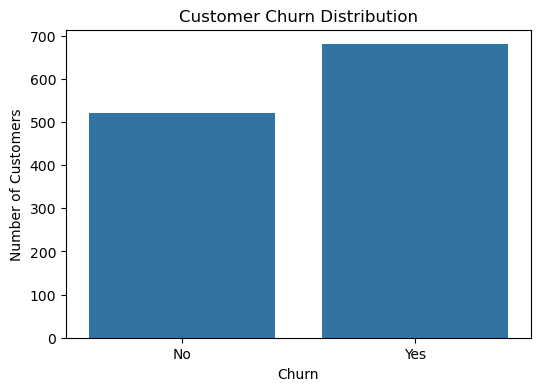

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

**Observation:**
The chart shows the number of customers who churned and those who did not churn. The two classes
are not exactly equal, so we should consider the evaluation metrics instead of relying only on accuracy.

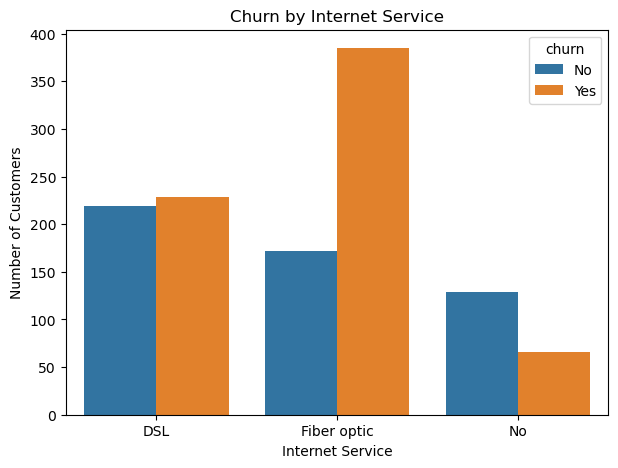

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='internet_service', hue='churn')

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()



**Observation:**
The chart shows how churn differs among customers using different internet services.

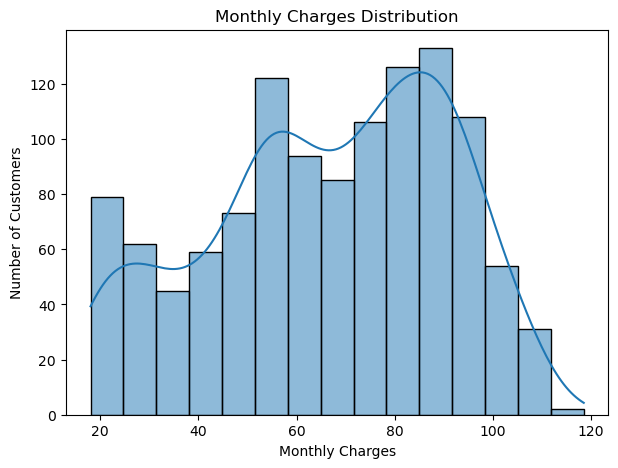

In [21]:
plt.figure(figsize=(7,5))

sns.histplot(data=df, x='monthly_charges', kde=True)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

**Observation:**
This graph shows how the monthly charges are distributed among customers and helps identify the common
monthly charge range.

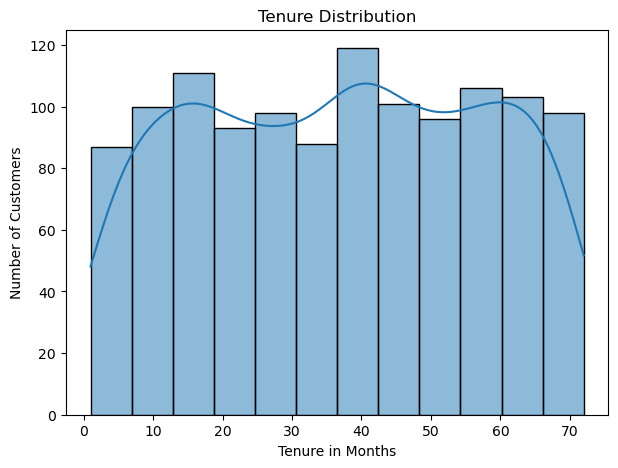

In [22]:
plt.figure(figsize=(7,5))

sns.histplot(data=df, x='tenure_months', kde=True)

plt.title('Tenure Distribution')
plt.xlabel('Tenure in Months')
plt.ylabel('Number of Customers')

plt.show()

**Observation:**
The graph shows the distribution of how long customers have stayed with the company.

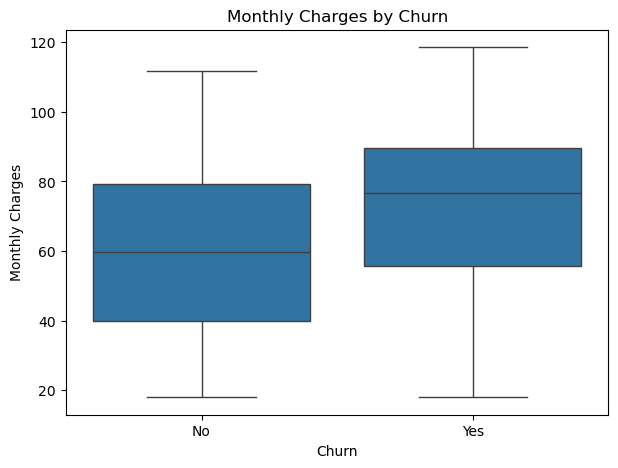

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='churn', y='monthly_charges')

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

**Observation:**
The boxplot compares monthly charges between customers who churned and those who did not. It can help 
identify whether monthly charges differ between the two groups.

**6: Prepare Features and Target**

In [24]:
X = df.drop(columns=['churn', 'customer_id'])
y = df['churn']

In [25]:
X.head()

,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1


In [26]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: object

In [27]:
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:")
print(numeric_columns)

Numeric Columns:
Index(['age', 'tenure_months', 'monthly_charges', 'total_charges',
       'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb'],
      dtype='object')


In [28]:
categorical_columns = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['gender', 'region', 'contract_type', 'internet_service', 'tech_support',
       'online_security', 'paperless_billing', 'payment_method'],
      dtype='object')


**7: Train-Test Split**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (960, 15)
Testing data: (240, 15)


**8: Preprocessing**

In [31]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

This handles:

Missing numeric values → median
Missing categorical values → most frequent
Categorical data → One-Hot Encoding
Numeric data → StandardScaler

**9. Train TWO Models**

I'll use:

Logistic Regression
Random Forest

In [33]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**10. Model Evaluation**

In [35]:
y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression")
print("-------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_lr, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_pred_lr, pos_label='Yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
-------------------
Accuracy: 0.7583333333333333
Precision: 0.7671232876712328
Recall: 0.8235294117647058
F1 Score: 0.7943262411347518

Confusion Matrix:
[[ 70  34]
 [ 24 112]]

Classification Report:
              precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240



In [36]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest")
print("-------------")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_pred_rf, pos_label='Yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
-------------
Accuracy: 0.7
Precision: 0.7285714285714285
Recall: 0.75
F1 Score: 0.7391304347826086

Confusion Matrix:
[[ 66  38]
 [ 34 102]]

Classification Report:
              precision    recall  f1-score   support

          No       0.66      0.63      0.65       104
         Yes       0.73      0.75      0.74       136

    accuracy                           0.70       240
   macro avg       0.69      0.69      0.69       240
weighted avg       0.70      0.70      0.70       240



In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, pos_label='Yes'),
        precision_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, pos_label='Yes'),
        recall_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr, pos_label='Yes'),
        f1_score(y_test, y_pred_rf, pos_label='Yes')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.758333,0.767123,0.823529,0.794326
1,Random Forest,0.700000,0.728571,0.750000,0.739130


**11. Select the Final Model**

In [38]:
best_model_name = results.loc[results['F1 Score'].idxmax(), 'Model']

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [39]:
if best_model_name == 'Logistic Regression':
    final_model = logistic_model
else:
    final_model = random_forest_model

print("Final model selected:", best_model_name)

Final model selected: Logistic Regression


**Final Model Selection:**
I compared Logistic Regression and Random Forest using accuracy, precision, recall, and F1 score.
I selected the model with the better overall evaluation performance. F1 score and recall are 
particularly useful because the objective is to identify customers who may churn.

**12. Save the Final Model**

In [40]:
joblib.dump(final_model, 'churn_pipeline.pkl')

print("Model saved successfully!")

Model saved successfully!


**13. Reload the Saved Model**

In [41]:
loaded_model = joblib.load('churn_pipeline.pkl')

print("Model loaded successfully!")


Model loaded successfully!


In [42]:
sample_customer = pd.DataFrame({
    'age': [35],
    'gender': ['Male'],
    'region': ['South'],
    'tenure_months': [12],
    'monthly_charges': [70],
    'total_charges': [840],
    'contract_type': ['Month-to-month'],
    'internet_service': ['Fiber optic'],
    'tech_support': ['No'],
    'online_security': ['No'],
    'paperless_billing': ['Yes'],
    'payment_method': ['Electronic check'],
    'num_support_calls': [4],
    'late_payments_last_year': [2],
    'avg_monthly_usage_gb': [100]
})

In [43]:
prediction = loaded_model.predict(sample_customer)

print("Predicted Churn:", prediction[0])

Predicted Churn: Yes


In [44]:
probability = loaded_model.predict_proba(sample_customer)

print("Probability of No Churn:", probability[0][0])
print("Probability of Churn:", probability[0][1])

Probability of No Churn: 0.020917106947661135
Probability of Churn: 0.9790828930523389
